# Actividad individual opcional Nº 2 — Análisis Exploratorio de Datos (EDA)

**Mousist, Jorge Martín** — Inteligencia Artificial (IUA)

**Consigna:** realizar un EDA básico del dataset seleccionado: estadística descriptiva, tipos de
variables, relaciones entre variables e incluir al menos 3 gráficos.

**Dataset:** *FIFA World Cup 2026 — Squads and Players*, uno de los sets de datos provistos
por la cátedra. Se usan dos de sus
tablas, `squads_and_players.csv` (un registro por jugador convocado) y `teams.csv` (un registro
por selección), que se cruzan por `team_id`. La unidad de análisis es el **jugador**.

## 1. Carga de los datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

jugadores = pd.read_csv('dataset/squads_and_players.csv')
equipos = pd.read_csv('dataset/teams.csv')

print('jugadores:', jugadores.shape)
print('equipos  :', equipos.shape)
jugadores.head(3)

jugadores: (1248, 10)
equipos  : (48, 8)


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4


In [2]:
# Se cruzan las dos tablas por team_id y se agregan dos variables derivadas:
# la edad al inicio del torneo y el valor de mercado expresado en millones de euros.
df = jugadores.merge(equipos, on='team_id')

df['edad'] = ((pd.Timestamp('2026-06-11') - pd.to_datetime(df['date_of_birth'])).dt.days / 365.25).astype(int)
df['valor_millones'] = (df['market_value_eur'] / 1_000_000).round(2)

df = df[['player_name', 'team_name', 'confederation', 'position',
         'edad', 'height_cm', 'valor_millones', 'caps', 'goals', 'elo_rating']]

print(f'Dataset de análisis: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset de análisis: 1248 filas × 10 columnas


,player_name,team_name,confederation,position,edad,height_cm,valor_millones,caps,goals,elo_rating
0,José Raúl Rangel,Mexico,CONCACAF,GK,26,190,8.93,15,0,1810
1,Jorge Eduardo Sanchez,Mexico,CONCACAF,DEF,28,176,24.63,59,3,1810
2,César Jasib Montes,Mexico,CONCACAF,DEF,29,191,10.91,69,4,1810
3,Edson Omar Alvarez,Mexico,CONCACAF,DEF,28,180,10.88,100,7,1810
4,Johan Felipe Vasquez,Mexico,CONCACAF,DEF,27,182,18.27,47,3,1810


## 2. Primera inspección: nulos y duplicados

In [3]:
print('Valores nulos por columna:')
print(df.isna().sum())
print()
print('Filas duplicadas:', df.duplicated().sum())

Valores nulos por columna:
player_name       0
team_name         0
confederation     0
position          0
edad              0
height_cm         0
valor_millones    0
caps              0
goals             0
elo_rating        0
dtype: int64

Filas duplicadas: 0


No hay ningún valor nulo ni ninguna fila duplicada. Es un buen punto de partida, pero conviene
no quedarse solamente con eso: que no falten datos no garantiza que los datos que están sean
correctos.


### 2.1. Un chequeo más allá de los nulos

`isna()` solo detecta celdas vacías. Un dato mal cargado que igual tiene contenido pasa
desapercibido. Como `player_name` debería ser único por jugador, lo uso como control.

In [4]:
print(f'Filas                      : {len(df)}')
print(f'Nombres distintos          : {df["player_name"].nunique()}')
print(f'Nombres que se repiten     : {(df["player_name"].value_counts() > 1).sum()}')
print()

repetidos = df['player_name'].value_counts()
repetidos = repetidos[repetidos > 1]
print('Nombres repetidos y cuántas veces aparecen:')
print(repetidos.to_string())

Filas                      : 1248
Nombres distintos          : 1241
Nombres que se repiten     : 2

Nombres repetidos y cuántas veces aparecen:
player_name
Mc           7
Ali Ahmed    2


In [5]:
# Miro los registros involucrados para entender si son errores o casos legítimos
for nombre in repetidos.index:
    print(f'--- "{nombre}" ---')
    print(df[df['player_name'] == nombre][
        ['player_name', 'team_name', 'position', 'edad', 'height_cm', 'caps', 'goals']
    ].to_string(index=False))
    print()

--- "Mc" ---
player_name   team_name position  edad  height_cm  caps  goals
         Mc    Scotland      MID    29        193    71     15
         Mc    Scotland      MID    31        178    87     21
         Mc    Scotland      MID    34        183    59      3
         Mc    Scotland      DEF    29        189    50      1
         Mc         USA      MID    27        180    67     12
         Mc         USA      DEF    27        186    29      0
         Mc New Zealand      MID    27        180    34      5

--- "Ali Ahmed" ---
player_name    team_name position  edad  height_cm  caps  goals
  Ali Ahmed       Canada      FWD    25        180    25      1
  Ali Ahmed Saudi Arabia       GK    35        178     9      0



Son dos situaciones distintas:

- **`Ali Ahmed` (2 registros):** un homónimo real. Son dos jugadores diferentes, de Canadá y
  Arabia Saudita, con puesto, club y estadísticas distintas. No es un error.
- **`Mc` (7 registros):** acá sí hay un problema. El apellido quedó **truncado en la carga**:
  son jugadores de Escocia, Estados Unidos y Nueva Zelanda cuyo apellido empieza con "Mc" y se
  cortó justo ahí. El resto de sus columnas (club, altura, partidos, goles) están completas y
  son distintas entre sí, así que **son siete jugadores reales con el nombre mal cargado**, no
  siete filas duplicadas.

In [6]:
# Confirmo que el problema viene del archivo original y no de cómo lo leí
print(jugadores.loc[jugadores['player_name'] == 'Mc',
                    ['player_id', 'player_name', 'club_team', 'caps', 'goals']].to_string(index=False))

 player_id player_name         club_team  caps  goals
       290          Mc        SSC Napoli    71     15
       293          Mc    Aston Villa FC    87     21
       309          Mc   Norwich City FC    59      3
       312          Mc GNK Dinamo Zagreb    50      1
       320          Mc       Juventus FC    67     12
       334          Mc       Toulouse FC    29      0
       722          Mc      Silkeborg IF    34      5


**Conclusión sobre la calidad:** el dataset no tiene nulos ni duplicados, pero sí tiene
**7 registros (0,6 %) con el nombre truncado**. No afecta al análisis, porque `player_name` es
un identificador y ninguna conclusión depende de él: todas las variables que uso son numéricas
o categóricas y están completas. Pero conviene dejarlo asentado, porque si más adelante hubiera
que cruzar este dataset con otro usando el nombre como clave, esas siete filas fallarían.

## 3. Tipos de variables

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player_name     1248 non-null   object 
 1   team_name       1248 non-null   object 
 2   confederation   1248 non-null   object 
 3   position        1248 non-null   object 
 4   edad            1248 non-null   int64  
 5   height_cm       1248 non-null   int64  
 6   valor_millones  1248 non-null   float64
 7   caps            1248 non-null   int64  
 8   goals           1248 non-null   int64  
 9   elo_rating      1248 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 97.6+ KB


In [8]:
# La clasificación conceptual la asigno yo; el dtype y la cantidad de valores
# únicos los leo del propio DataFrame para que la tabla no pueda quedar desfasada.
clasificacion = {
    'player_name':    ('categórica nominal', 'nombre del jugador (identificador)'),
    'team_name':      ('categórica nominal', 'selección a la que pertenece'),
    'confederation':  ('categórica nominal', 'confederación de la selección'),
    'position':       ('categórica nominal', 'puesto: GK, DEF, MID, FWD'),
    'edad':           ('numérica discreta',  'años cumplidos al inicio del torneo'),
    'height_cm':      ('numérica continua',  'altura en centímetros'),
    'valor_millones': ('numérica continua',  'valor de mercado en millones de €'),
    'caps':           ('numérica discreta',  'partidos jugados con la selección'),
    'goals':          ('numérica discreta',  'goles con la selección'),
    'elo_rating':     ('numérica continua',  'rating Elo del equipo del jugador'),
}

tipos = pd.DataFrame({
    'tipo':           {c: clasificacion[c][0] for c in df.columns},
    'dtype':          df.dtypes.astype(str),
    'valores únicos': df.nunique(),
    'descripción':    {c: clasificacion[c][1] for c in df.columns},
})

tipos


,tipo,dtype,valores únicos,descripción
player_name,categórica nominal,object,1241,nombre del jugador (identificador)
team_name,categórica nominal,object,48,selección a la que pertenece
confederation,categórica nominal,object,6,confederación de la selección
position,categórica nominal,object,4,"puesto: GK, DEF, MID, FWD"
edad,numérica discreta,int64,26,años cumplidos al inicio del torneo
height_cm,numérica continua,int64,40,altura en centímetros
valor_millones,numérica continua,float64,502,valor de mercado en millones de €
caps,numérica discreta,int64,137,partidos jugados con la selección
goals,numérica discreta,int64,55,goles con la selección
elo_rating,numérica continua,int64,48,rating Elo del equipo del jugador


Hay **4 variables categóricas nominales** y **6 numéricas**. `height_cm` y `elo_rating` se tratan
como continuas aunque estén redondeadas a un entero, porque miden magnitudes continuas; `edad`,
`caps` y `goals` son conteos, es decir, discretas.

## 4. Estadística descriptiva

In [9]:
numericas = ['edad', 'height_cm', 'valor_millones', 'caps', 'goals']
df[numericas].describe().round(2)

,edad,height_cm,valor_millones,caps,goals
count,1248.00,1248.00,1248.00,1248.00,1248.00
mean,27.45,182.78,15.50,34.99,4.52
std,4.27,6.83,23.45,32.23,10.40
min,17.00,160.00,0.02,0.00,0.00
25%,24.00,178.00,2.60,11.00,0.00
50%,27.00,183.00,6.57,26.00,1.00
75%,30.00,188.00,18.00,50.00,4.00
max,43.00,205.00,200.00,229.00,143.00


In [10]:
# Medidas de tendencia central, dispersión y forma
resumen = pd.DataFrame({
    'media':      df[numericas].mean(),
    'mediana':    df[numericas].median(),
    'moda':       df[numericas].mode().iloc[0],
    'desvío':     df[numericas].std(),
    'CV (σ/μ)':   df[numericas].std() / df[numericas].mean(),
    'IQR':        df[numericas].quantile(0.75) - df[numericas].quantile(0.25),
    'asimetría':  df[numericas].skew(),
    'curtosis':   df[numericas].kurtosis(),
}).round(2)

resumen

,media,mediana,moda,desvío,CV (σ/μ),IQR,asimetría,curtosis
edad,27.45,27.00,27.0,4.27,0.16,6.0,0.33,-0.09
height_cm,182.78,183.00,185.0,6.83,0.04,10.0,-0.09,-0.25
valor_millones,15.50,6.57,2.0,23.45,1.51,15.4,3.26,14.20
caps,34.99,26.00,4.0,32.23,0.92,39.0,1.61,3.40
goals,4.52,1.00,0.0,10.40,2.30,4.0,5.98,51.57


**Lectura:**

- En `edad` y `height_cm` la media y la mediana prácticamente coinciden y la asimetría es cercana
  a 0: son distribuciones **simétricas**, bien resumidas por la media.
- `valor_millones` tiene media 15,50 M€ contra mediana 6,57 M€, asimetría +3,26 y curtosis +14,2:
  una **cola derecha muy larga** producida por un puñado de estrellas. Acá la media engaña y
  conviene usar la mediana.
- El coeficiente de variación confirma el orden: `height_cm` es la variable más homogénea
  (CV 0,04) y `goals` la más dispersa (CV 2,30).

### 4.1. Variables categóricas

In [11]:
for col in ['position', 'confederation']:
    frec = pd.DataFrame({
        'frecuencia absoluta': df[col].value_counts(),
        'frecuencia relativa': (df[col].value_counts(normalize=True) * 100).round(1),
    })
    print(f'--- {col} ({df[col].nunique()} categorías) ---')
    print(frec, end='\n\n')

--- position (4 categorías) ---
          frecuencia absoluta  frecuencia relativa
position                                          
DEF                       421                 33.7
MID                       369                 29.6
FWD                       313                 25.1
GK                        145                 11.6

--- confederation (6 categorías) ---
               frecuencia absoluta  frecuencia relativa
confederation                                          
UEFA                           416                 33.3
CAF                            260                 20.8
AFC                            234                 18.8
CONCACAF                       156                 12.5
CONMEBOL                       156                 12.5
OFC                             26                  2.1



In [12]:
# Cardinalidad y concentración de cada variable categórica
categoricas = df.select_dtypes(include='object').columns.tolist()

pd.DataFrame({
    'categorías': df[categoricas].nunique(),
    'moda': df[categoricas].apply(lambda s: s.value_counts().index[0]),
    'frecuencia de la moda': df[categoricas].apply(lambda s: s.value_counts().iloc[0]),
    'proporción de la moda': df[categoricas].apply(lambda s: s.value_counts(normalize=True).iloc[0]).round(3),
})

,categorías,moda,frecuencia de la moda,proporción de la moda
player_name,1241,Mc,7,0.006
team_name,48,Mexico,26,0.021
confederation,6,UEFA,416,0.333
position,4,DEF,421,0.337


`position` resume a los 1248 jugadores en apenas 4 categorías, mientras que `team_name` tiene 48
con exactamente 26 jugadores cada una, así que su distribución es perfectamente uniforme.

Lo que llama la atención es `player_name`: **1241 valores únicos para 1248 filas**. Si fuera un
identificador limpio deberían ser 1248. Esa diferencia es la que se investiga en la sección 2.1.


El reparto por puesto sigue la estructura habitual de un plantel (más defensores que delanteros y
sólo tres arqueros por plantel: 145 sobre 1248 jugadores). En `confederation`, UEFA aporta el 33 %
de los convocados, coherente con la cantidad de plazas europeas en el torneo.

## 5. Outliers

Para detectar valores atípicos uso el **criterio del rango intercuartil**: se considera atípico
todo valor que queda por debajo de `Q1 − 1,5 × IQR` o por encima de `Q3 + 1,5 × IQR`.

In [13]:
def resumen_outliers(data, columnas):
    """Detecta outliers por el criterio de 1,5 x IQR y arma una tabla resumen."""
    filas = {}
    for col in columnas:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        fuera = (data[col] < lim_inf) | (data[col] > lim_sup)
        filas[col] = {
            'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'límite inferior': lim_inf, 'límite superior': lim_sup,
            'outliers': int(fuera.sum()),
            '% del total': round(100 * fuera.mean(), 2),
            'máximo observado': data[col].max(),
        }
    return pd.DataFrame(filas).T

outliers = resumen_outliers(df, numericas)
outliers.round(2)

,Q1,Q3,IQR,límite inferior,límite superior,outliers,% del total,máximo observado
edad,24.0,30.0,6.0,15.00,39.00,7.0,0.56,43.0
height_cm,178.0,188.0,10.0,163.00,203.00,2.0,0.16,205.0
valor_millones,2.6,18.0,15.4,-20.49,41.09,113.0,9.05,200.0
caps,11.0,50.0,39.0,-47.50,108.50,48.0,3.85,229.0
goals,0.0,4.0,4.0,-6.00,10.00,133.0,10.66,143.0


Las dos variables con más atípicos son `goals` y `valor_millones`, justamente las de mayor
asimetría. `edad` y `height_cm`, que eran las distribuciones simétricas, casi no tienen.
La detección y la forma de la distribución cuentan la misma historia.

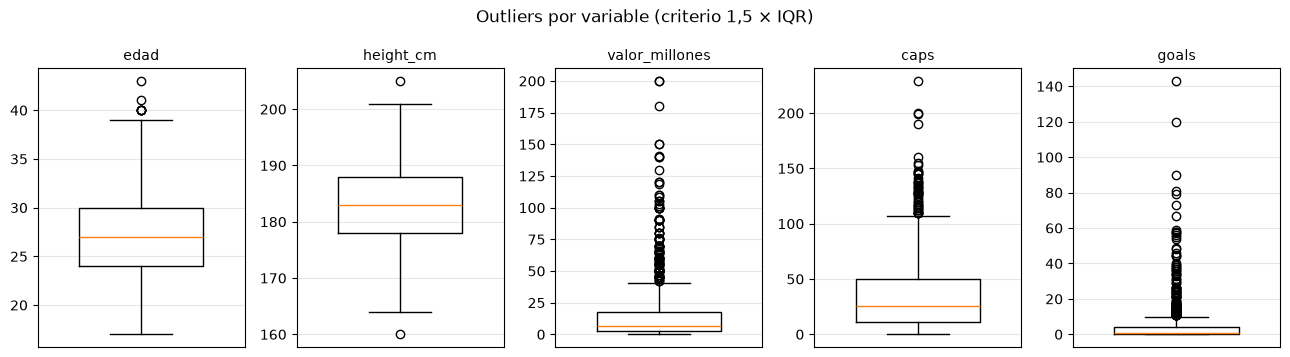

In [14]:
# Boxplot de cada variable numérica: la caja es el IQR y los puntos sueltos son los outliers
fig, axes = plt.subplots(1, len(numericas), figsize=(13, 3.6))

for ax, col in zip(axes, numericas):
    ax.boxplot(df[col], widths=0.6)
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Outliers por variable (criterio 1,5 × IQR)')
plt.tight_layout()
plt.show()

In [15]:
# ¿Quiénes son esos valores extremos? Miro los tres más altos de cada variable
for col in numericas:
    print(f'--- {col}: valores más altos ---')
    print(df.nlargest(3, col)[['player_name', 'team_name', 'position', col]].to_string(index=False))
    print()

--- edad: valores más altos ---
              player_name team_name position  edad
    Craig Sinclair Gordon  Scotland       GK    43
Ronaldo Cristiano Ronaldo  Portugal      FWD    41
Francisco Guillermo Ochoa    Mexico       GK    40

--- height_cm: valores más altos ---
         player_name              team_name position  height_cm
     Florian Wiegele                Austria       GK        205
    Stjepan Radeljic Bosnia and Herzegovina      DEF        201
Álvaro David Montero               Colombia       GK        201

--- valor_millones: valores más altos ---
         player_name team_name position  valor_millones
  Lamine Yamal Yamal     Spain      FWD           200.0
Erling Braut Haaland    Norway      FWD           200.0
       Kylian Mbappe    France      FWD           180.0

--- caps: valores más altos ---
              player_name team_name position  caps
Ronaldo Cristiano Ronaldo  Portugal      FWD   229
      Lionel Andrés Messi Argentina      FWD   200
              Luk

**Decisión: los conservo.** Los casos extremos no son errores de carga ni ruido, son jugadores
reales y perfectamente identificables: los valores de mercado más altos corresponden a las
estrellas del torneo y los máximos de `caps` y `goals` a los veteranos con más trayectoria
internacional. Eliminarlos borraría justo la parte del fenómeno que hace interesante al dataset.

Lo que sí hay que hacer es **tenerlos en cuenta al describir y al modelar**: por eso uso la
mediana y el IQR en lugar de la media y el desvío, y por eso el valor de mercado convendría
transformarlo (por ejemplo con logaritmo) antes de usarlo en un modelo.

In [16]:
# La transformación logarítmica sobre el valor de mercado: cómo cambia la asimetría
antes = df['valor_millones'].skew()
despues = np.log10(df['valor_millones']).skew()

print(f'Asimetría del valor de mercado          : {antes:.2f}')
print(f'Asimetría del logaritmo del valor       : {despues:.2f}')
print(f'La transformación reduce la asimetría en {abs(antes) - abs(despues):.2f} puntos.')

Asimetría del valor de mercado          : 3.26
Asimetría del logaritmo del valor       : -0.39
La transformación reduce la asimetría en 2.87 puntos.


## 6. Relaciones entre variables

In [17]:
# Relación numérica–numérica: matriz de correlación de Pearson
df[numericas + ['elo_rating']].corr().round(2)

,edad,height_cm,valor_millones,caps,goals,elo_rating
edad,1.00,0.10,-0.22,0.61,0.29,-0.01
height_cm,0.10,1.00,-0.03,-0.10,-0.06,0.06
valor_millones,-0.22,-0.03,1.00,-0.01,0.10,0.57
caps,0.61,-0.10,-0.01,1.00,0.61,0.05
goals,0.29,-0.06,0.10,0.61,1.00,0.07
elo_rating,-0.01,0.06,0.57,0.05,0.07,1.00


Las relaciones más fuertes son:

- **`edad` ~ `caps` = +0,61** y **`caps` ~ `goals` = +0,61**: cuanto más veterano es el jugador,
  más partidos y más goles acumula con su selección. Es la relación esperable, y es acumulativa.
- **`elo_rating` ~ `valor_millones` = +0,57**: los planteles de las selecciones más fuertes valen
  más. Es la relación más informativa del dataset.
- **`edad` ~ `valor_millones` = −0,22**: la relación es **negativa**. El mercado paga proyección,
  no trayectoria.
- `height_cm` no se relaciona con ninguna otra numérica (todas entre −0,10 y +0,10). Sí se
  relaciona, en cambio, con una categórica: el puesto (ver gráfico 3).

### 6.1. Pearson frente a Spearman

Pearson mide relación **lineal**; Spearman mide relación **monótona**, trabajando sobre los
rangos en lugar de los valores. Cuando una relación existe pero no es una recta, Spearman la
detecta y Pearson no. Comparo los dos métodos para ver si alguna relación se me escapó.

In [18]:
todas = numericas + ['elo_rating']
pearson = df[todas].corr()
spearman = df[todas].corr(method='spearman')

pares = [(a, b) for j, a in enumerate(todas) for b in todas[j + 1:]]
comparacion = pd.DataFrame([{
    'par': f'{a} ~ {b}',
    'Pearson': pearson.loc[a, b],
    'Spearman': spearman.loc[a, b],
    'diferencia absoluta': abs(spearman.loc[a, b]) - abs(pearson.loc[a, b]),
} for a, b in pares]).set_index('par')

comparacion.sort_values('diferencia absoluta', ascending=False).round(3)

,Pearson,Spearman,diferencia absoluta
par,,,
height_cm ~ goals,-0.059,-0.205,0.146
valor_millones ~ elo_rating,0.573,0.645,0.073
valor_millones ~ goals,0.100,0.170,0.071
valor_millones ~ caps,-0.009,0.067,0.058
height_cm ~ caps,-0.100,-0.132,0.032
height_cm ~ valor_millones,-0.025,-0.044,0.018
edad ~ valor_millones,-0.224,-0.237,0.012
height_cm ~ elo_rating,0.056,0.066,0.010
caps ~ goals,0.614,0.622,0.008


El caso más claro es **`height_cm ~ goals`**: Pearson da un valor cercano a cero, que se leería
como "no hay relación", mientras que Spearman detecta una relación negativa bastante más
marcada. Tiene sentido: los jugadores más altos son arqueros y defensores, que son los que menos
convierten, pero esa caída no sigue una línea recta. Es exactamente la limitación de Pearson que
vimos en la teoría.

In [19]:
# Relación categórica–numérica: valor de mercado y altura según el puesto
df.groupby('position')[['valor_millones', 'height_cm', 'edad']].median().round(1)

,valor_millones,height_cm,edad
position,,,
DEF,6.0,184.0,27.0
FWD,7.7,182.0,26.0
GK,3.2,190.0,30.0
MID,7.9,180.0,27.0


Los arqueros son los más altos (mediana 190 cm) y a la vez los peor pagados (3,18 M€ de mediana,
menos de la mitad que un mediocampista). Los mediocampistas y delanteros concentran el valor.

## 7. Gráficos

Los tres gráficos siguientes cubren los tres tipos de análisis: la distribución de una variable,
la relación entre dos numéricas y la relación entre una numérica y una categórica.

### Gráfico 1 — Distribución del valor de mercado (histograma)

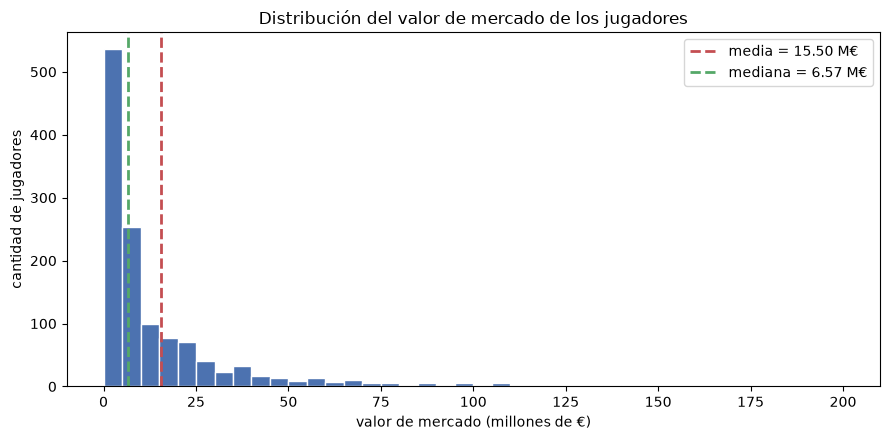

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(df['valor_millones'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(df['valor_millones'].mean(), color='#C44E52', linestyle='--', linewidth=2,
           label=f"media = {df['valor_millones'].mean():.2f} M€")
ax.axvline(df['valor_millones'].median(), color='#55A868', linestyle='--', linewidth=2,
           label=f"mediana = {df['valor_millones'].median():.2f} M€")

ax.set_title('Distribución del valor de mercado de los jugadores')
ax.set_xlabel('valor de mercado (millones de €)')
ax.set_ylabel('cantidad de jugadores')
ax.legend()
plt.tight_layout()
plt.show()

La distribución es **fuertemente asimétrica a la derecha** (asimetría +3,26): la gran mayoría de
los jugadores vale menos de 20 M€ y una minoría se estira hasta los 200 M€. Por eso la media
(línea roja) queda muy por encima de la mediana (línea verde) y no representa bien al jugador
típico.

### Gráfico 2 — Edad vs. partidos internacionales (dispersión)

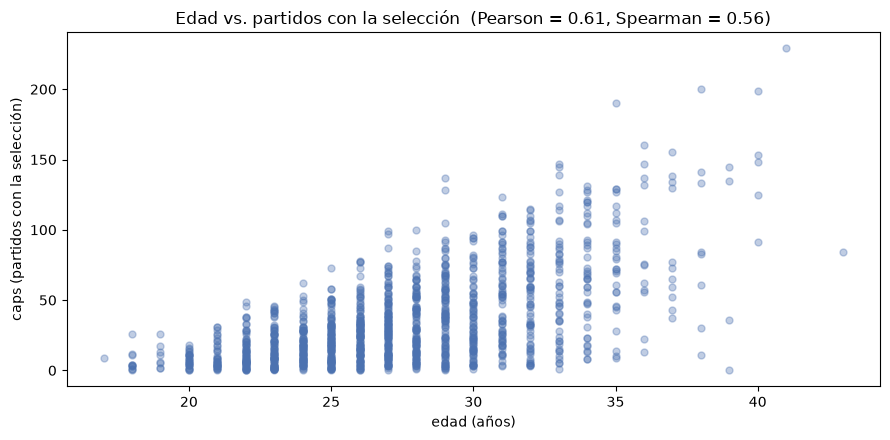

In [21]:
r_pearson = df['edad'].corr(df['caps'])
r_spearman = df['edad'].corr(df['caps'], method='spearman')

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.scatter(df['edad'], df['caps'], alpha=0.35, s=25, color='#4C72B0')

ax.set_title(f'Edad vs. partidos con la selección  (Pearson = {r_pearson:.2f}, '
             f'Spearman = {r_spearman:.2f})')
ax.set_xlabel('edad (años)')
ax.set_ylabel('caps (partidos con la selección)')
plt.tight_layout()
plt.show()

Se ve una **relación positiva y creciente**: los caps se acumulan con los años, por lo que ningún
jugador joven puede tener muchos partidos (esquina inferior izquierda poblada, superior izquierda
vacía). La dispersión aumenta con la edad porque a partir de los 28 conviven titulares históricos
de más de 100 partidos con jugadores de convocatoria reciente.

### Gráfico 3 — Altura por puesto (boxplot)

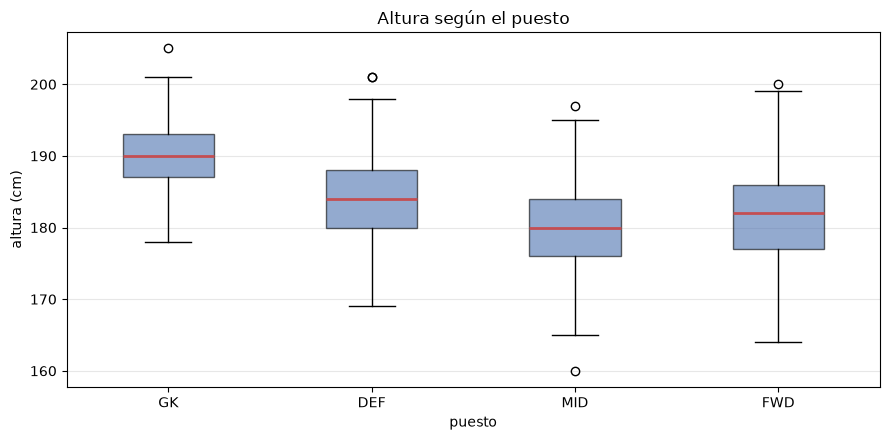

In [22]:
orden = ['GK', 'DEF', 'MID', 'FWD']
datos = [df.loc[df['position'] == p, 'height_cm'] for p in orden]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.boxplot(datos, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6),
           medianprops=dict(color='#C44E52', linewidth=2))
ax.set_xticks(range(1, len(orden) + 1))
ax.set_xticklabels(orden)

ax.set_title('Altura según el puesto')
ax.set_xlabel('puesto')
ax.set_ylabel('altura (cm)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El puesto **sí** explica la altura, algo que ninguna variable numérica lograba: la mediana baja de
**190 cm en los arqueros** a 184 (DEF), 182 (FWD) y 180 cm (MID). Las cajas de GK (187–193 cm) y
MID (176–184 cm) no se superponen: la diferencia entre esos dos grupos es real y no producto del
azar.

## 8. Conclusiones

1. El dataset es **balanceado y casi limpio**: 1248 jugadores, 26 por selección, sin nulos ni
   duplicados. La única falla de calidad son 7 registros con el nombre truncado en `Mc`,
   que no afectan al análisis porque ninguna conclusión depende del nombre del jugador.
2. Hay **dos familias de distribuciones**. `edad` y `height_cm` son simétricas y se resumen bien
   con la media; `valor_millones`, `caps` y `goals` tienen una cola derecha larga y hay que
   describirlas con la **mediana y el IQR**.
3. La variable que mejor se relaciona con el valor de mercado no es individual sino del equipo:
   **`elo_rating` (+0,57)**. La experiencia (`caps`) es indiferente al valor y la edad se
   relaciona **negativamente** (−0,22): el mercado paga proyección.
4. La relación **categórica–numérica más nítida** es altura por puesto (GK 190 > DEF 184 >
   FWD 182 > MID 180 cm), invisible para la matriz de correlación.
5. Como resultado práctico para un modelo posterior: `valor_millones` conviene transformarla
   (por ejemplo con logaritmo) antes de usarla, y `position` y `elo_rating` son las candidatas
   más informativas.
6. Los **outliers** detectados por el criterio de 1,5 × IQR se concentran en `goals` y
   `valor_millones`, y **no son errores**: son las estrellas del mercado y los veteranos con
   más trayectoria. Se conservan, pero condicionan cómo hay que describir esas variables.
